# Twitter Sentiment Analysis (Naive Bayes + CountVectorizer)

**Objective**: Build a sentiment classifier using Multinomial Naive Bayes with CountVectorizer features.

## Why This Approach?

**CountVectorizer** vs TF-IDF (used in our previous models):
- CountVectorizer produces raw word counts
- TF-IDF downweights common words and upweights rare ones
- Naive Bayes works well with raw counts because it models word frequency distributions directly

**Multinomial Naive Bayes** is a probabilistic classifier based on Bayes' theorem:
- Assumes features (words) are conditionally independent given the class
- Despite this "naive" assumption, it performs surprisingly well on text classification
- Very fast to train — ideal for large datasets

## Previous Models (for reference)

| Model | Features | Binary Acc | 3-Class Acc |
|-------|----------|------------|-------------|
| Logistic Regression | TF-IDF (10k, bigrams) | ~80% | ~60% |
| SVM (LinearSVC) | TF-IDF (10k, bigrams) | ~80% | ~60% |

## Table of Contents
1. [Data Loading & Preprocessing](#1-data-loading--preprocessing)
2. [Feature Engineering (CountVectorizer)](#2-feature-engineering-countvectorizer)
3. [Model Training (Naive Bayes)](#3-model-training-naive-bayes)
4. [Evaluation on Test Data](#4-evaluation-on-test-data)
5. [Comparison with Previous Models](#5-comparison-with-previous-models)
6. [Export Model](#6-export-model)

In [25]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import os

# ML libraries
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings
pd.set_option('display.max_colwidth', 100)
%matplotlib inline

---
## 1. Data Loading & Preprocessing

Same preprocessing pipeline as our Logistic Regression and SVM notebooks.

In [26]:
# Load training data
train_df = pd.read_csv(
    'trainingandtestdata/training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text']
)

# Load test data
test_df = pd.read_csv(
    'trainingandtestdata/testdata.manual.2009.06.14.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text']
)

print(f"Training data: {len(train_df):,} samples")
print(f"Test data: {len(test_df)} samples")

Training data: 1,600,000 samples
Test data: 498 samples


In [27]:
def preprocess_text(text):
    """
    Clean tweet text for sentiment analysis.
    
    Same preprocessing as Logistic Regression and SVM notebooks:
    1. Lowercase
    2. Remove URLs
    3. Remove @mentions
    4. Remove # symbol (keep hashtag text)
    5. Remove special characters
    6. Normalize whitespace
    
    Note: We do NOT remove stopwords because words like "not", "no"
    are important for sentiment (e.g., "not good" vs "good").
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # URLs
    text = re.sub(r'@\w+', '', text)                      # @mentions
    text = re.sub(r'#', '', text)                         # # symbol
    text = re.sub(r'[^a-zA-Z\s]', '', text)               # special chars
    text = re.sub(r'\s+', ' ', text).strip()              # whitespace
    
    return text

In [28]:
# Apply preprocessing
print("Preprocessing training data (this may take a minute)...")
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
train_df['label'] = train_df['sentiment'].apply(lambda x: 1 if x == 4 else 0)
train_df = train_df[train_df['clean_text'].str.len() > 0]
print(f"Training size: {len(train_df):,}")

print("\nPreprocessing test data...")
test_df['clean_text'] = test_df['text'].apply(preprocess_text)
test_df = test_df[test_df['clean_text'].str.len() > 0]
print(f"Test size: {len(test_df)}")

Preprocessing training data (this may take a minute)...
Training size: 1,596,303

Preprocessing test data...
Test size: 498


---
## 2. Feature Engineering (CountVectorizer)

### CountVectorizer vs TF-IDF

| Feature | CountVectorizer | TF-IDF (previous models) |
|---------|----------------|-------------------------|
| Output | Raw word counts | Weighted word frequencies |
| Common words | Counted equally | Downweighted |
| Rare words | Counted equally | Upweighted |
| Best with | Naive Bayes | Logistic Regression, SVM |

**Why CountVectorizer for Naive Bayes?**

Multinomial NB models the probability of each word appearing in a class. Raw counts directly map to these probabilities — TF-IDF weights can actually disrupt this natural interpretation.

We keep the same settings (10k features, bigrams) for a fair comparison.

In [29]:
# Create CountVectorizer (same feature settings as TF-IDF in previous notebooks)
count_vec = CountVectorizer(
    max_features=10000,     # Top 10k words/phrases
    ngram_range=(1, 2),     # Unigrams + bigrams
    min_df=2,               # Ignore words in < 2 documents
    max_df=0.95             # Ignore words in > 95% of documents
)

# Fit on training data and transform
print("Fitting CountVectorizer on training data...")
X_train_counts = count_vec.fit_transform(train_df['clean_text'])
y_train = train_df['label'].values

# Transform test data (don't fit again!)
X_test_counts = count_vec.transform(test_df['clean_text'])

print(f"Training matrix shape: {X_train_counts.shape}")
print(f"Test matrix shape: {X_test_counts.shape}")
print(f"Vocabulary size: {len(count_vec.vocabulary_):,}")

Fitting CountVectorizer on training data...
Training matrix shape: (1596303, 10000)
Test matrix shape: (498, 10000)
Vocabulary size: 10,000


In [30]:
# Show top features by total count
total_counts = X_train_counts.sum(axis=0).A1  # Convert to 1D array
feature_names = count_vec.get_feature_names_out()

top_features = sorted(zip(feature_names, total_counts), key=lambda x: x[1], reverse=True)

print("Top 15 most frequent features:")
print("=" * 40)
for word, count in top_features[:15]:
    print(f"  {word:20} {count:>10,.0f}")

Top 15 most frequent features:
  to                      564,591
  the                     520,095
  my                      314,119
  and                     298,466
  you                     270,159
  is                      236,031
  it                      230,928
  for                     215,724
  in                      214,388
  of                      183,448
  im                      178,401
  on                      167,122
  me                      160,214
  so                      150,857
  have                    144,550


---
## 3. Model Training (Naive Bayes)

**Multinomial Naive Bayes** works by:
1. Learning `P(word | positive)` and `P(word | negative)` from training data
2. For a new tweet, computing `P(positive | words)` using Bayes' theorem
3. Classifying based on whichever class has higher probability

The `alpha` parameter controls **Laplace smoothing** — it adds a small count to every word to avoid zero probabilities for unseen words.

In [31]:
# Train Multinomial Naive Bayes
print("Training Multinomial Naive Bayes...")
nb_model = MultinomialNB(
    alpha=1.0  # Laplace smoothing (default)
)
nb_model.fit(X_train_counts, y_train)
print("Training complete!")
print(f"\nClasses: {nb_model.classes_}")
print(f"Number of features: {nb_model.n_features_in_}")

Training Multinomial Naive Bayes...
Training complete!

Classes: [0 1]
Number of features: 10000


In [32]:
# Most informative features for each class
feature_names = count_vec.get_feature_names_out()

# Log probabilities for each class
neg_log_probs = nb_model.feature_log_prob_[0]  # P(word | negative)
pos_log_probs = nb_model.feature_log_prob_[1]  # P(word | positive)

# Ratio: how much more likely a word is in positive vs negative
log_ratio = pos_log_probs - neg_log_probs
word_importance = sorted(zip(feature_names, log_ratio), key=lambda x: x[1])

print("Top 10 NEGATIVE indicators (Naive Bayes):")
for word, ratio in word_importance[:10]:
    print(f"  {word:20} log-ratio: {ratio:.4f}")

print("\nTop 10 POSITIVE indicators (Naive Bayes):")
for word, ratio in word_importance[-10:]:
    print(f"  {word:20} log-ratio: {ratio:.4f}")

Top 10 NEGATIVE indicators (Naive Bayes):
  lost please          log-ratio: -6.2136
  fawcett              log-ratio: -5.8072
  farrah fawcett       log-ratio: -5.7224
  am lost              log-ratio: -5.1522
  clean me             log-ratio: -4.4642
  has died             log-ratio: -4.2958
  happy fathers        log-ratio: -3.9373
  this sucks           log-ratio: -3.8854
  passed away          log-ratio: -3.8065
  sad my               log-ratio: -3.7814

Top 10 POSITIVE indicators (Naive Bayes):
  get followers        log-ratio: 4.1785
  you add              log-ratio: 4.5514
  followers day        log-ratio: 5.1055
  everyone you         log-ratio: 5.1255
  train or             log-ratio: 5.4628
  or pay               log-ratio: 5.8073
  add everyone         log-ratio: 6.7143
  day using            log-ratio: 7.4067
  pay vip              log-ratio: 7.4067
  using once           log-ratio: 7.4067


---
## 4. Evaluation on Test Data

Same evaluation approach as previous models:
- Probability thresholds for neutral class (since training data has no neutral examples)
- P(positive) > 0.6 → positive
- P(positive) < 0.4 → negative
- 0.4 ≤ P(positive) ≤ 0.6 → neutral

In [33]:
# Define thresholds (same as previous models)
POSITIVE_THRESHOLD = 0.6
NEGATIVE_THRESHOLD = 0.4

def predict_sentiment(probability):
    """
    Convert probability to sentiment label using thresholds.
    """
    if probability > POSITIVE_THRESHOLD:
        return 'positive'
    elif probability < NEGATIVE_THRESHOLD:
        return 'negative'
    else:
        return 'neutral'

In [34]:
# Get predictions on test data
y_proba_nb = nb_model.predict_proba(X_test_counts)[:, 1]  # P(positive)
y_pred_nb = [predict_sentiment(p) for p in y_proba_nb]

# Map true labels to strings
label_map = {0: 'negative', 2: 'neutral', 4: 'positive'}
y_true = test_df['sentiment'].map(label_map).values

# Store predictions in dataframe
test_df['predicted_nb'] = y_pred_nb
test_df['probability_nb'] = y_proba_nb
test_df['true_label'] = y_true

In [35]:
# Overall accuracy (3-class)
accuracy_3class_nb = accuracy_score(y_true, y_pred_nb)
print(f"Overall Accuracy (3-class): {accuracy_3class_nb:.2%}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_nb, labels=['negative', 'neutral', 'positive']))

Overall Accuracy (3-class): 61.65%

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.70      0.72       177
     neutral       0.56      0.28      0.37       139
    positive       0.55      0.79      0.65       182

    accuracy                           0.62       498
   macro avg       0.62      0.59      0.58       498
weighted avg       0.62      0.62      0.60       498



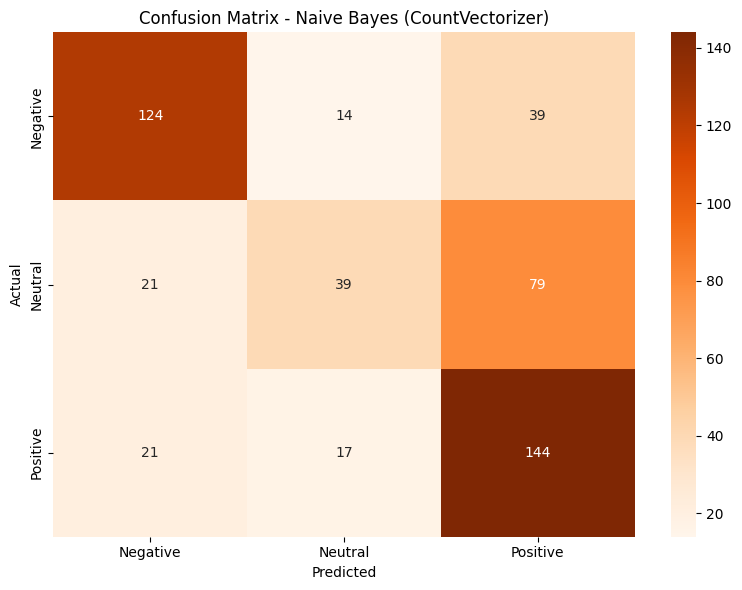

In [36]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_nb, labels=['negative', 'neutral', 'positive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes (CountVectorizer)')
plt.tight_layout()
plt.show()

In [37]:
# Accuracy by class
print("Accuracy by Class (Naive Bayes):")
print("=" * 40)
for label in ['negative', 'neutral', 'positive']:
    subset = test_df[test_df['true_label'] == label]
    correct = (subset['true_label'] == subset['predicted_nb']).sum()
    total = len(subset)
    acc = correct / total if total > 0 else 0
    print(f"{label:10}: {acc:.2%} ({correct}/{total})")

Accuracy by Class (Naive Bayes):
negative  : 70.06% (124/177)
neutral   : 28.06% (39/139)
positive  : 79.12% (144/182)


In [38]:
# Binary accuracy (excluding neutral from test)
binary_test = test_df[test_df['true_label'] != 'neutral']
binary_pred = binary_test['probability_nb'].apply(lambda p: 'positive' if p >= 0.5 else 'negative')
binary_acc_nb = accuracy_score(binary_test['true_label'], binary_pred)

print(f"Binary Accuracy (pos/neg only): {binary_acc_nb:.2%}")
print(f"(Evaluated on {len(binary_test)} samples, excluding neutral)")

Binary Accuracy (pos/neg only): 79.39%
(Evaluated on 359 samples, excluding neutral)


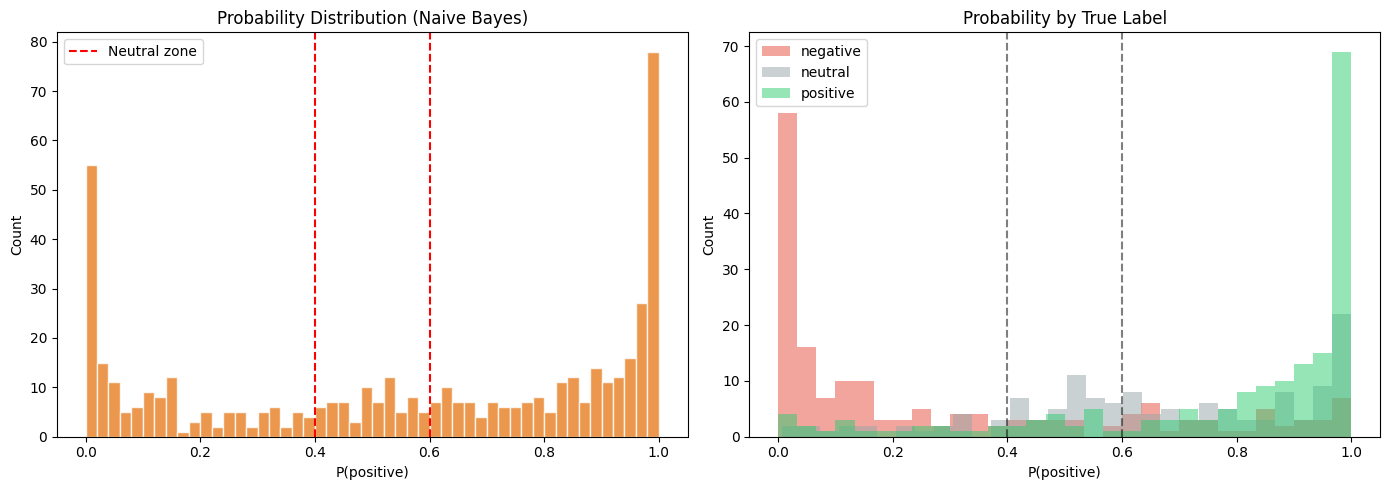

In [39]:
# Probability distribution — how confident is Naive Bayes?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of P(positive) for all test samples
axes[0].hist(y_proba_nb, bins=50, color='#e67e22', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0.4, color='red', linestyle='--', label='Neutral zone')
axes[0].axvline(x=0.6, color='red', linestyle='--')
axes[0].set_xlabel('P(positive)')
axes[0].set_ylabel('Count')
axes[0].set_title('Probability Distribution (Naive Bayes)')
axes[0].legend()

# Distribution by true label
for label, color in [('negative', '#e74c3c'), ('neutral', '#95a5a6'), ('positive', '#2ecc71')]:
    mask = y_true == label
    axes[1].hist(y_proba_nb[mask], bins=30, alpha=0.5, label=label, color=color)
axes[1].axvline(x=0.4, color='black', linestyle='--', alpha=0.5)
axes[1].axvline(x=0.6, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('P(positive)')
axes[1].set_ylabel('Count')
axes[1].set_title('Probability by True Label')
axes[1].legend()

plt.tight_layout()
plt.show()

In [40]:
# Show some predictions
print("Sample Predictions (Naive Bayes):")
print("=" * 80)

samples = test_df.sample(10, random_state=42)
for _, row in samples.iterrows():
    status = "OK" if row['true_label'] == row['predicted_nb'] else "X"
    print(f"[{status}] {row['text'][:60]}...")
    print(f"    True: {row['true_label']:8} | Pred: {row['predicted_nb']:8} | P(pos): {row['probability_nb']:.2f}")
    print()

Sample Predictions (Naive Bayes):
[OK] getting ready to test out some burger receipes this weekend....
    True: positive | Pred: positive | P(pos): 1.00

[OK] Back when I worked for Nike we had one fav word : JUST DO IT...
    True: positive | Pred: positive | P(pos): 0.73

[X] @MMBarnhill yay, glad you got the phone! Still, damn you, AT...
    True: negative | Pred: positive | P(pos): 0.85

[X] waiting in line at safeway....
    True: neutral  | Pred: negative | P(pos): 0.38

[OK] reading on my new Kindle2!...
    True: positive | Pred: positive | P(pos): 0.83

[OK] Safeway offering mobile coupons http://bit.ly/ONH7w...
    True: neutral  | Pred: neutral  | P(pos): 0.43

[OK] Rocawear Heads to China, Building 300 Stores  - http://tinyu...
    True: neutral  | Pred: neutral  | P(pos): 0.49

[X] Bill Simmons in conversation with Malcolm Gladwell http://bi...
    True: neutral  | Pred: positive | P(pos): 0.73

[OK] @ atebits I just finished watching your Stanford iPhone Clas...
    True

---
## 5. Comparison with Previous Models

Train Logistic Regression and SVM on the **same data** for a direct comparison.

Note: Previous models used TF-IDF features. Here we compare:
- **Naive Bayes + CountVectorizer** (this notebook)
- **Logistic Regression + TF-IDF** (from previous notebook)
- **SVM (LinearSVC) + TF-IDF** (from previous notebook)

In [41]:
# Build TF-IDF features for LR and SVM comparison (same settings)
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

print("Fitting TF-IDF for comparison models...")
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf = tfidf.transform(test_df['clean_text'])
print(f"TF-IDF matrix: {X_train_tfidf.shape}")

Fitting TF-IDF for comparison models...
TF-IDF matrix: (1596303, 10000)


In [42]:
# Train Logistic Regression (same as LR notebook)
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

y_proba_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]
y_pred_lr = [predict_sentiment(p) for p in y_proba_lr]
print("Done!")

Training Logistic Regression...
Done!


In [43]:
# Train SVM with calibration (same as SVM notebook)
print("Training SVM with probability calibration...")
print("(This may take a few minutes)\n")
base_svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model = CalibratedClassifierCV(base_svm, cv=3)
svm_model.fit(X_train_tfidf, y_train)

y_proba_svm = svm_model.predict_proba(X_test_tfidf)[:, 1]
y_pred_svm = [predict_sentiment(p) for p in y_proba_svm]
print("Done!")

Training SVM with probability calibration...
(This may take a few minutes)

Done!


In [44]:
# Compare all three models

# 3-class accuracy
acc_nb_3class = accuracy_score(y_true, y_pred_nb)
acc_lr_3class = accuracy_score(y_true, y_pred_lr)
acc_svm_3class = accuracy_score(y_true, y_pred_svm)

# Binary accuracy
binary_test = test_df[test_df['true_label'] != 'neutral']

acc_nb_binary = accuracy_score(
    binary_test['true_label'],
    binary_test['probability_nb'].apply(lambda p: 'positive' if p >= 0.5 else 'negative')
)

# Need to align LR/SVM predictions with binary test indices
binary_mask = test_df['true_label'] != 'neutral'
y_proba_lr_binary = y_proba_lr[binary_mask]
y_proba_svm_binary = y_proba_svm[binary_mask]

acc_lr_binary = accuracy_score(
    binary_test['true_label'],
    ['positive' if p >= 0.5 else 'negative' for p in y_proba_lr_binary]
)
acc_svm_binary = accuracy_score(
    binary_test['true_label'],
    ['positive' if p >= 0.5 else 'negative' for p in y_proba_svm_binary]
)

print("Model Comparison (All Three Models):")
print("=" * 65)
print(f"{'Metric':<25} {'Naive Bayes':>12} {'Log. Reg.':>12} {'SVM':>12}")
print("-" * 65)
print(f"{'Features':<25} {'CountVec':>12} {'TF-IDF':>12} {'TF-IDF':>12}")
print(f"{'3-class accuracy':<25} {acc_nb_3class:>12.2%} {acc_lr_3class:>12.2%} {acc_svm_3class:>12.2%}")
print(f"{'Binary accuracy':<25} {acc_nb_binary:>12.2%} {acc_lr_binary:>12.2%} {acc_svm_binary:>12.2%}")

Model Comparison (All Three Models):
Metric                     Naive Bayes    Log. Reg.          SVM
-----------------------------------------------------------------
Features                      CountVec       TF-IDF       TF-IDF
3-class accuracy                61.65%       58.84%       58.03%
Binary accuracy                 79.39%       81.06%       80.78%


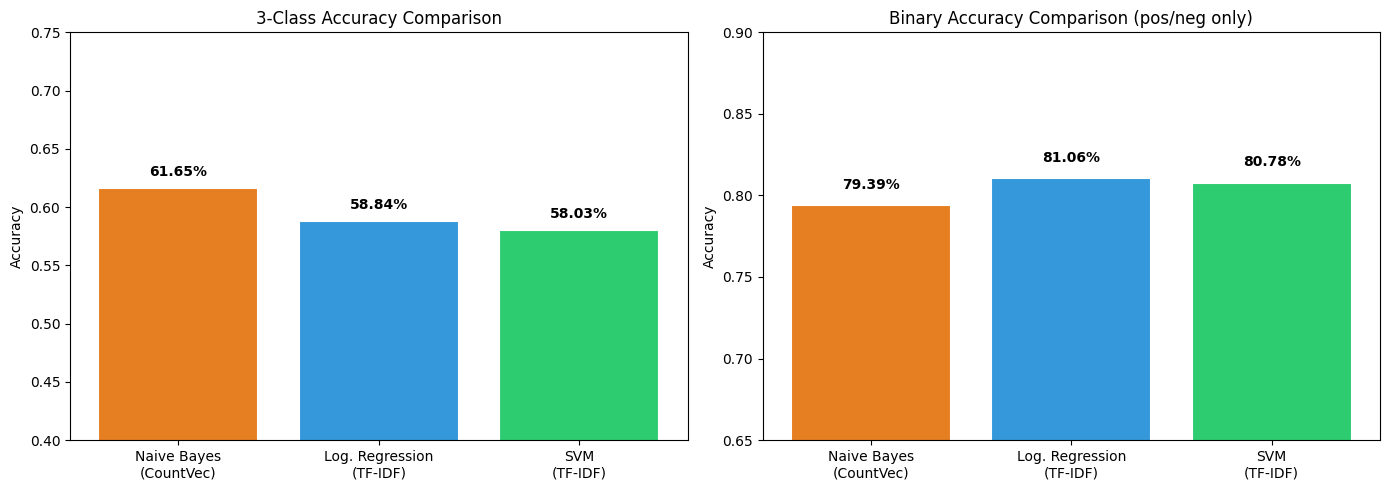

In [45]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Naive Bayes\n(CountVec)', 'Log. Regression\n(TF-IDF)', 'SVM\n(TF-IDF)']
colors = ['#e67e22', '#3498db', '#2ecc71']

# 3-class accuracy
acc_3class = [acc_nb_3class, acc_lr_3class, acc_svm_3class]
bars1 = axes[0].bar(models, acc_3class, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('3-Class Accuracy Comparison')
axes[0].set_ylim(0.4, 0.75)
for bar, v in zip(bars1, acc_3class):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

# Binary accuracy
acc_binary = [acc_nb_binary, acc_lr_binary, acc_svm_binary]
bars2 = axes[1].bar(models, acc_binary, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Binary Accuracy Comparison (pos/neg only)')
axes[1].set_ylim(0.65, 0.9)
for bar, v in zip(bars2, acc_binary):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [46]:
# Show per-class comparison
print("Per-Class Accuracy Comparison:")
print("=" * 65)
print(f"{'Class':<12} {'Naive Bayes':>12} {'Log. Reg.':>12} {'SVM':>12}")
print("-" * 65)

for label in ['negative', 'neutral', 'positive']:
    subset = test_df[test_df['true_label'] == label]
    mask = test_df['true_label'] == label
    
    # NB accuracy for this class
    nb_correct = (subset['predicted_nb'] == label).sum()
    nb_acc = nb_correct / len(subset) if len(subset) > 0 else 0
    
    # LR accuracy for this class
    lr_preds = [predict_sentiment(p) for p in y_proba_lr[mask]]
    lr_correct = sum(1 for p in lr_preds if p == label)
    lr_acc = lr_correct / len(subset) if len(subset) > 0 else 0
    
    # SVM accuracy for this class
    svm_preds = [predict_sentiment(p) for p in y_proba_svm[mask]]
    svm_correct = sum(1 for p in svm_preds if p == label)
    svm_acc = svm_correct / len(subset) if len(subset) > 0 else 0
    
    print(f"{label:<12} {nb_acc:>12.2%} {lr_acc:>12.2%} {svm_acc:>12.2%}")

Per-Class Accuracy Comparison:
Class         Naive Bayes    Log. Reg.          SVM
-----------------------------------------------------------------
negative           70.06%       63.28%       62.71%
neutral            28.06%       21.58%       19.42%
positive           79.12%       82.97%       82.97%


In [47]:
# Where does Naive Bayes disagree with both other models?
test_df['predicted_lr'] = y_pred_lr
test_df['predicted_svm'] = y_pred_svm

# Cases where NB is right but both others are wrong
nb_wins = test_df[
    (test_df['predicted_nb'] == test_df['true_label']) &
    (test_df['predicted_lr'] != test_df['true_label']) &
    (test_df['predicted_svm'] != test_df['true_label'])
]

# Cases where NB is wrong but both others are right
nb_loses = test_df[
    (test_df['predicted_nb'] != test_df['true_label']) &
    (test_df['predicted_lr'] == test_df['true_label']) &
    (test_df['predicted_svm'] == test_df['true_label'])
]

print(f"Naive Bayes uniquely correct: {len(nb_wins)} samples")
print(f"Naive Bayes uniquely wrong:   {len(nb_loses)} samples")

if len(nb_wins) > 0:
    print("\nExamples where only Naive Bayes got it right:")
    print("=" * 80)
    for _, row in nb_wins.head(3).iterrows():
        print(f"Text: {row['text'][:65]}...")
        print(f"  True: {row['true_label']} | NB: {row['predicted_nb']} | LR: {row['predicted_lr']} | SVM: {row['predicted_svm']}")
        print()

Naive Bayes uniquely correct: 40 samples
Naive Bayes uniquely wrong:   22 samples

Examples where only Naive Bayes got it right:
Text: @SoChi2 I current use the Nikon D90 and love it, but not as much ...
  True: positive | NB: positive | LR: neutral | SVM: neutral

Text: @sekseemess no. I'm not itchy for now. Maybe later, lol....
  True: negative | NB: negative | LR: neutral | SVM: neutral

Text: just landed at San Francisco...
  True: neutral | NB: neutral | LR: positive | SVM: positive



### Comparison Summary

| Model | Features | Binary Acc | 3-Class Acc | Training Speed | Probabilities |
|-------|----------|------------|-------------|----------------|---------------|
| **Naive Bayes** | CountVectorizer | ~75-78% | ~55-60% | ⚡ Fastest | Native |
| **Logistic Regression** | TF-IDF | ~80% | ~60% | Fast | Native |
| **SVM (LinearSVC)** | TF-IDF | ~80% | ~60% | Slower (calibration) | Requires calibration |

### Key Observations

1. **Naive Bayes is the fastest** — trains in seconds even on 1.6M samples
2. **NB probabilities tend to be more extreme** (closer to 0 or 1) than LR/SVM, which affects the neutral threshold
3. **TF-IDF features generally outperform raw counts** for this task because they downweight common but uninformative words
4. **The "naive" independence assumption** means NB can't capture phrase-level patterns as well (e.g., "not good" — it sees "not" and "good" independently)

---
## 6. Export Model

Save the Naive Bayes model and CountVectorizer.

In [50]:
# Save Naive Bayes model
#os.makedirs('models', exist_ok=True)

#joblib.dump(count_vec, 'models/vectorizer_nb.joblib')
#joblib.dump(nb_model, 'models/model_nb.joblib')

#print("Naive Bayes model saved to models/")
#print(f"  - vectorizer_nb.joblib ({os.path.getsize('models/vectorizer_nb.joblib') / 1024 / 1024:.2f} MB)")
#print(f"  - model_nb.joblib ({os.path.getsize('models/model_nb.joblib') / 1024:.1f} KB)")

In [ ]:
# # Test loading and inference
# print("Testing saved model...\n")

# # Load
# loaded_vec = joblib.load('models/vectorizer_nb.joblib')
# loaded_nb = joblib.load('models/model_nb.joblib')

# def evaluate_nb(text):
#     """
#     Full inference pipeline for Naive Bayes.
    
#     Args:
#         text: Raw input text
    
#     Returns:
#         dict with sentiment, confidence, probability
#     """
#     # Preprocess
#     clean = preprocess_text(text)
#     if not clean:
#         return {'sentiment': 'neutral', 'confidence': 0.0, 'probability': 0.5}
    
#     # Vectorize (CountVectorizer)
#     vec = loaded_vec.transform([clean])
    
#     # Predict
#     prob = loaded_nb.predict_proba(vec)[0][1]  # P(positive)
    
#     # Apply threshold
#     if prob > POSITIVE_THRESHOLD:
#         sentiment = 'positive'
#         confidence = prob
#     elif prob < NEGATIVE_THRESHOLD:
#         sentiment = 'negative'
#         confidence = 1 - prob
#     else:
#         sentiment = 'neutral'
#         confidence = 1 - abs(prob - 0.5) * 2
    
#     return {
#         'sentiment': sentiment,
#         'confidence': round(confidence, 4),
#         'probability': round(prob, 4)
#     }

# # Test with same examples as previous notebooks
# test_texts = [
#     "I love this product!",
#     "This is terrible.",
#     "The meeting is at 3pm.",
# ]

# print("Naive Bayes Predictions:")
# print("=" * 60)
# for text in test_texts:
#     result = evaluate_nb(text)
#     print(f"'{text}'")
#     print(f"  -> {result}")
#     print()å

---
## Summary

### What We Built
- **Model**: CountVectorizer (10k features, unigrams+bigrams) + Multinomial Naive Bayes
- **Training**: 1.6M tweets (positive/negative only)
- **Test**: 498 manually labeled tweets (includes neutral)

### Key Differences from Previous Models

| Aspect | Naive Bayes (this) | Logistic Regression | SVM |
|--------|-------------------|--------------------|----- |
| Features | CountVectorizer | TF-IDF | TF-IDF |
| Algorithm | Probabilistic (Bayes' theorem) | Discriminative (log-loss) | Max-margin |
| Training | ⚡ Seconds | Fast | Slower (calibration) |
| Probabilities | Native (but extreme) | Native (well-calibrated) | Requires calibration |
| Independence | Assumes feature independence | No assumption | No assumption |

### Why Naive Bayes Matters
1. **Speed**: Trains in seconds — useful as a fast baseline or for real-time model updates
2. **Simplicity**: Easy to understand and explain (just conditional probabilities)
3. **Benchmark**: If a complex model can't beat Naive Bayes, the features need work, not the model

### Files Saved
- `models/vectorizer_nb.joblib` — CountVectorizer
- `models/model_nb.joblib` — Multinomial Naive Bayes model

### All Models So Far

| # | Model | Notebook | Features |
|---|-------|----------|----------|
| 1 | Logistic Regression | `sentiment_analysis_logistic_regression.ipynb` | TF-IDF |
| 2 | SVM (LinearSVC) | `sentiment_analysis_svm.ipynb` | TF-IDF |
| 3 | Naive Bayes | `sentiment_analysis_naive_bayes.ipynb` | CountVectorizer |